# 로컬 데이터 로드

In [4]:
#컴퓨터에서 작업하려면 아래 코드의 주석을 제거하고 실행하면 됩니다
import pandas as pd
src_data = pd.read_csv('과일채소목록.csv',encoding='cp949')

# 공통 실습 코드

In [5]:
#Step 3. 훈련용 세트와 테스트용 세트로 나눕니다.
# '무게_g','길이_cm','색상','당도'에 따른 과일종류 분류
data = src_data[["무게_g", "길이_cm", "색상", "당도"]]
target = src_data.종류

# train, test 데이터 분리
from sklearn.model_selection import train_test_split
훈련용_data, 테스트용_data, 훈련용_target, 테스트용_target = train_test_split(
    data, target, test_size = 0.2, random_state = 40)

In [6]:
# 각각의 데이터 확인
print(훈련용_data.shape , 테스트용_data.shape)
print(훈련용_data)
print(훈련용_target)

(40, 4) (10, 4)
    무게_g  길이_cm  색상   당도
16   500   25.0   1  2.0
35   501    8.1   2  8.1
25  2001   30.5   1  8.1
21   250   25.0   3  7.5
44   351   20.1   1  1.4
41   501   25.1   1  2.1
23   270   26.0   3  8.5
36   401    7.6   2  7.3
5    100    3.5   3  6.0
13   400    6.5   2  6.5
39   601    8.6   2  8.1
17   380   22.0   1  1.5
43   401   23.1   1  1.1
24   290   29.0   3  9.0
3   1500   16.0   1  8.5
22   220   22.0   3  7.0
40   451   20.1   1  3.1
26  2501   25.1   1  7.1
34   111    3.7   3  7.6
20   280   28.0   3  8.0
28  1501   16.1   1  8.6
14   600    8.5   2  8.0
15   450   20.0   1  3.0
30   101    3.6   3  6.1
8    150    3.8   3  8.5
46   251   25.1   3  7.6
32    91    2.9   3  8.1
9    110    3.6   3  7.5
48   271   26.1   3  8.6
42   381   22.1   1  1.6
10   500    8.0   2  8.0
31   121    3.8   3  7.1
19   350   20.0   1  1.3
47   221   22.1   3  7.1
12   450    8.0   2  7.5
1   2500   25.0   1  7.0
37   451    8.1   2  7.6
7     90    2.8   3  8.0
27  1801 

In [7]:
from sklearn.ensemble import RandomForestClassifier
# 랜덤 포레스트 모델 생성
rfc = RandomForestClassifier(n_estimators = 10, n_jobs = -1, random_state = 40)

# 학습
rfc.fit(훈련용_data, 훈련용_target)

# 예측
print(rfc.predict(테스트용_data))

# score
print(rfc.score(테스트용_data, 테스트용_target))

['자두' '수박' '거봉포도' '참외' '거봉포도' '수박' '옥수수' '수박' '참외' '수박']
1.0


### 결과표 작성 및 시각화

In [8]:
# 테스트 데이터 확인
print(테스트용_data)

    무게_g  길이_cm  색상   당도
33   151    3.9   3  8.6
29  2201   21.1   1  9.6
49   291   29.1   3  9.1
38   401    6.6   2  6.6
45   281   28.1   3  8.1
0   2000   30.0   1  8.0
18   400   23.0   1  1.0
4   2200   21.0   1  9.5
11   400    7.5   2  7.2
2   1800   20.0   1  6.5


In [9]:
# 예측결과 데이터프레임을 만들고
# concat을 통해 기존 테스트 data와 예측결과 데이터를 합친다.
import pandas as pd

예측결과 = pd.DataFrame(rfc.predict(테스트용_data), columns = ['예측결과'])

result = pd.concat([테스트용_data.reset_index(drop = True), 예측결과], axis = 1)
print(result)

   무게_g  길이_cm  색상   당도  예측결과
0   151    3.9   3  8.6    자두
1  2201   21.1   1  9.6    수박
2   291   29.1   3  9.1  거봉포도
3   401    6.6   2  6.6    참외
4   281   28.1   3  8.1  거봉포도
5  2000   30.0   1  8.0    수박
6   400   23.0   1  1.0   옥수수
7  2200   21.0   1  9.5    수박
8   400    7.5   2  7.2    참외
9  1800   20.0   1  6.5    수박


In [10]:
from sklearn.metrics import classification_report

pred = rfc.predict(테스트용_data)

print(classification_report(테스트용_target, pred))

              precision    recall  f1-score   support

        거봉포도       1.00      1.00      1.00         2
          수박       1.00      1.00      1.00         4
         옥수수       1.00      1.00      1.00         1
          자두       1.00      1.00      1.00         1
          참외       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [ ]:
# k-fold 교차 검증
import numpy as np
from sklearn.model_selection import cross_validate , cross_val_score
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=10)

# cross_validate() : 검사 결과를 자세하게 보여주는 것
scores_1 = cross_validate(dt, 훈련용_data, 훈련용_target, cv = 3)
# cross_val_score() : 검사 결과 중에서 평균 점수만 보여주는 것

print('cross_validate 결과:', scores_1)
print('cross_validate 결과:', np.mean(scores_1['test_score']))


cross_validate 결과: {'fit_time': array([0.00259829, 0.00241017, 0.00151396]), 'score_time': array([0.00258183, 0.00246525, 0.00201249]), 'test_score': array([1., 1., 1.])}
cross_validate 결과: 1.0
cross_val_score 결과: 1.0


중요속성지표값: [0.43788379 0.18804429 0.15510803 0.21896389]


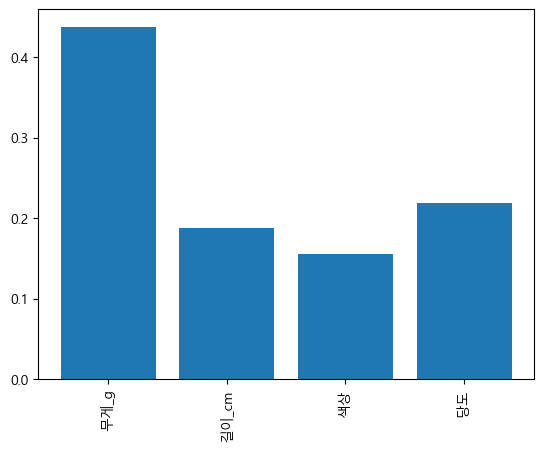

In [ ]:
# 중요 속성 지표값 출력

import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

imp = rfc.feature_importances_ 
print('중요속성지표값:',imp)

plt.figure()
plt.bar(range(len(imp)),imp)
plt.xticks(range(len(imp)),data.columns, rotation=90)
plt.show()